In [1]:
import sys
import os
import pandas as pd
import sqlite3

# Add the Backend directory to the Python path
backend_dir = os.path.abspath('..')
if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

import db_manager
import json
from ai_predictor import get_predictor

In [18]:
import importlib
import ml_models
importlib.reload(ml_models)
from ai_predictor import get_predictor

# Initialize database and load the AI predictor
db_manager.init_db()
predictor = get_predictor()

print(f"Model loaded: {predictor.model_name}")


DB Initialized successfully.
Model loaded: xgboost


In [19]:
# Fetch all distinct patients from the database
db_path = os.path.join(backend_dir, 'hospital_iot.db')
conn = sqlite3.connect(db_path)
patients_df = pd.read_sql_query("SELECT patient_id, age, gender, mobility_level, has_gastro_issue, has_uro_issue, self_reported_max_seconds FROM Patients", conn)
conn.close()

display(patients_df.head())

,patient_id,age,gender,mobility_level,has_gastro_issue,has_uro_issue,self_reported_max_seconds
0,P-1000,33,F,1,0,1,2160
1,P-1001,29,M,0,1,0,1200
2,P-1002,38,M,2,0,0,2280
3,P-1003,23,M,2,0,0,2280
4,P-1004,22,F,0,0,1,2160


In [20]:
# Test threshold predictions for the patients
results = []

for idx, row in patients_df.iterrows():
    patient_id = row['patient_id']
    # Get the latest structural features exactly as the main app would
    features = db_manager.get_patient_latest_features(patient_id)
    
    if features is None:
        results.append({
            'patient_id': patient_id,
            'status': 'No features available',
            'threshold_duration': None
        })
        continue
        
    # Search for threshold
    search_result = predictor.compute_threshold_for_patient(features, duration_range=(60, 5000))
    
    results.append({
        'patient_id': patient_id,
        'base_report_s': row['self_reported_max_seconds'],
        'gastro': row['has_gastro_issue'],
        'uro': row['has_uro_issue'],
        'mobility': row['mobility_level'],
        'threshold_duration': search_result.get('threshold_duration', 'Not Found'),
        'threshold_score': search_result.get('threshold_score', 'N/A'),
        'reason': search_result.get('reason', '')
    })

results_df = pd.DataFrame(results)
display(results_df)


Searching for patient threshold...
  Duration range: 60-5000s (step: 30s)
  Threshold limit: 0.2224 (scores lower than this are anomalies)
  Arming normals: 3 consecutive normal points
  Debounce: 3 steps
✓ Threshold found: 1740.0s (score fell to 0.9999)

Searching for patient threshold...
  Duration range: 60-5000s (step: 30s)
  Threshold limit: 0.2224 (scores lower than this are anomalies)
  Arming normals: 3 consecutive normal points
  Debounce: 3 steps
✓ Threshold found: 1740.0s (score fell to 0.9999)

Searching for patient threshold...
  Duration range: 60-5000s (step: 30s)
  Threshold limit: 0.2224 (scores lower than this are anomalies)
  Arming normals: 3 consecutive normal points
  Debounce: 3 steps
✓ Threshold found: 1740.0s (score fell to 0.9999)

Searching for patient threshold...
  Duration range: 60-5000s (step: 30s)
  Threshold limit: 0.2224 (scores lower than this are anomalies)
  Arming normals: 3 consecutive normal points
  Debounce: 3 steps
✓ Threshold found: 1740.0s

,patient_id,base_report_s,gastro,uro,mobility,threshold_duration,threshold_score,reason
0,P-1000,2160,0,1,1,1740.0,0.999874,threshold_found_after_arming
1,P-1001,1200,1,0,0,1740.0,0.999874,threshold_found_after_arming
2,P-1002,2280,0,0,2,1740.0,0.999881,threshold_found_after_arming
3,P-1003,2280,0,0,2,1740.0,0.999881,threshold_found_after_arming
4,P-1004,2160,0,1,0,1740.0,0.999874,threshold_found_after_arming
...,...,...,...,...,...,...,...,...
95,P-1095,1740,0,0,1,1740.0,0.999881,threshold_found_after_arming
96,P-1096,1620,0,0,1,1740.0,0.999874,threshold_found_after_arming
97,P-1097,2280,1,1,0,1740.0,0.999881,threshold_found_after_arming
98,P-1098,1680,0,0,1,1740.0,0.999893,threshold_found_after_arming



Searching for patient threshold...
  Duration range: 60-3000s (step: 30s)
  Threshold limit: 0.2224 (scores lower than this are anomalies)
  Arming normals: 3 consecutive normal points
  Debounce: 3 steps
✓ Threshold found: 1740.0s (score fell to 0.9999)


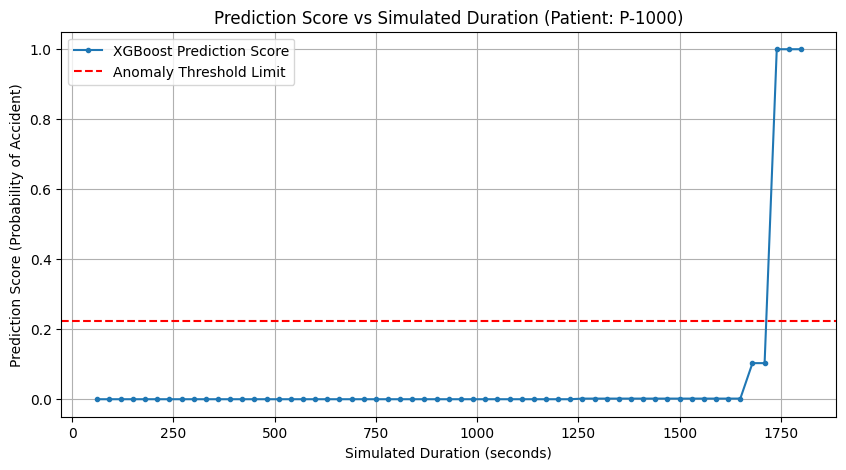


--- Feature state at 1740s ---
feature_id                                     190
log_id                                       17498
patient_id                                  P-1000
duration_seconds                            1740.0
time_of_day_id                                   5
hour_of_day                                     22
day_of_week                                      6
is_weekend                                       1
time_since_last_log_minutes                  179.0
is_accident                                      0
mean_duration_7d                             736.6
max_duration_7d                             2394.0
min_duration_7d                              259.0
std_duration_7d                         424.201768
log_count_7d                                    40
tod_deep_night_count_7d                          3
tod_early_morning_count_7d                      10
tod_late_morning_count_7d                       11
tod_afternoon_count_7d                          10

In [24]:
# We can also manually check how the score changes across durations for one specific patient to debug why it stops at 1740s
if not results_df.empty and 'threshold_duration' in results_df.columns:
    sample_patient = "P_02" if "P_02" in results_df['patient_id'].values else results_df.iloc[0]['patient_id']
    features = db_manager.get_patient_latest_features(sample_patient)
    
    if features is not None:
        # Temporarily enable prints from predictor by calling it again
        search_result = predictor.compute_threshold_for_patient(features, duration_range=(60, 3000))
        scores_by_dur = search_result['scores_by_duration']
        
        # Convert to dataframe for easy plotting
        df_scores = pd.DataFrame(list(scores_by_dur.items()), columns=['Duration', 'Prediction_Score'])
        
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(df_scores['Duration'], df_scores['Prediction_Score'], marker='.', label='XGBoost Prediction Score')
        plt.axhline(y=predictor.get_default_threshold(), color='r', linestyle='--', label='Anomaly Threshold Limit')
        plt.title(f"Prediction Score vs Simulated Duration (Patient: {sample_patient})")
        plt.xlabel("Simulated Duration (seconds)")
        plt.ylabel("Prediction Score (Probability of Accident)")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # Print out the exact features at the threshold moment
        print("\n--- Feature state at 1740s ---")
        print(predictor._recalculate_duration_features(features, 1740))

In [25]:
results_df['threshold_duration'].value_counts()


threshold_duration
1740.0    100
Name: count, dtype: int64

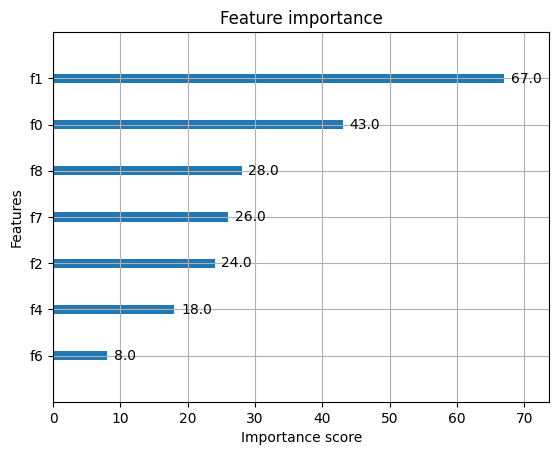

In [10]:
import xgboost as xgb
import matplotlib.pyplot as plt

booster = predictor.model.model
xgb.plot_importance(booster)
plt.show()

In [9]:
# Print scores around 1740
f = df_scores[(df_scores['Duration'] >= 1600) & (df_scores['Duration'] <= 1800)]
display(f)

,Duration,Prediction_Score
52,1620.0,0.000058
53,1650.0,0.000058
54,1680.0,0.000058
55,1710.0,0.000058
56,1740.0,0.921055
57,1770.0,0.921055
58,1800.0,0.921055


In [22]:
scores = booster.get_booster().get_score(importance_type='gain')
importance_df = pd.Series(scores).sort_values(ascending=False)

# map fn to actual feature names
feature_names = predictor.feature_names
feature_map = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_df.index = importance_df.index.map(feature_map)

display(importance_df)

num__report_minus_duration       3568.971680
num__duration_seconds            1762.566406
num__duration_to_report_ratio     374.289734
num__mean_duration_7d               0.249280
num__hour_of_day                    0.036751
num__accident_ratio_7d              0.011688
num__max_duration_7d                0.010036
dtype: float64

In [14]:
display(results_df[results_df['patient_id'] == 'P_02'])

,patient_id,base_report_s,gastro,uro,mobility,threshold_duration,threshold_score,reason
101,P_02,3000,1,1,2,1740.0,0.921055,threshold_found_after_arming


In [15]:
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT duration_seconds, is_accident FROM Toilet_Logs WHERE is_accident = 1", conn)
conn.close()

display(df.describe())

,duration_seconds,is_accident
count,511.000000,511.0
mean,5652.763209,1.0
std,2125.698273,0.0
min,45.000000,1.0
25%,4144.000000,1.0
50%,5177.000000,1.0
75%,6642.000000,1.0
max,14299.000000,1.0


In [23]:
conn = sqlite3.connect(db_path)
df_feat = pd.read_sql_query("SELECT duration_seconds, is_accident FROM Toilet_Log_Features", conn)
conn.close()

# Let's see max duration for normal, and min duration for accident
display(df_feat.groupby('is_accident').describe())

duration_seconds                                                   \
                       count         mean          std    min     25%     50%   
is_accident                                                                     
0                    17987.0   831.119475   433.429394   65.0   495.0   749.0   
1                      497.0  2851.623742  1048.464752  223.0  2250.0  2850.0   

                             
                75%     max  
is_accident                  
0            1081.0  2737.0  
1            3515.0  5822.0